In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# Tesla EA Deliveries and Production Data (2015–2025)

## End-to-End Machine Learning Pipeline

### Project Objectives

This project demonstrates a complete Machine Learning pipeline using Tesla deliveries and production data.

The workflow includes:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Model Evaluation
- Time Series Visualization

# Import Required Libraries

The following libraries are imported for:

- Data manipulation
- Data visualization
- Machine Learning
- Model evaluation

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

The Tesla dataset is loaded into a Pandas DataFrame for analysis.

In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Dataset Overview

In this section, we examine the dataset structure by checking:

- Dataset shape
- Column names
- Data types
- Summary statistics

This helps us understand the dataset before preprocessing.

In [4]:
print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns.tolist())

print("\n")

print("="*60)
print("DATA INFORMATION")
print("="*60)
df.info()

print("\n")

print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)
display(df.describe())

DATASET SHAPE
(2640, 12)


COLUMN NAMES
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 no

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Data Cleaning

Data cleaning is an essential preprocessing step.

We will check:

- Missing values
- Duplicate records

A clean dataset improves model performance and reliability.

In [5]:
print("="*60)
print("MISSING VALUES")
print("="*60)

display(df.isnull().sum())

print("\n")

print("="*60)
print("DUPLICATE ROWS")
print("="*60)

print(df.duplicated().sum())

MISSING VALUES


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64



DUPLICATE ROWS
0


In [6]:
df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(2640, 12)


# Exploratory Data Analysis (EDA)

EDA helps us understand the distribution, trends, and relationships within the dataset.

The following visualizations analyze:

- Estimated Deliveries by Year
- Production Units by Year
- Tesla Model Distribution
- Correlation between numerical features
- Relationship between Production and Deliveries

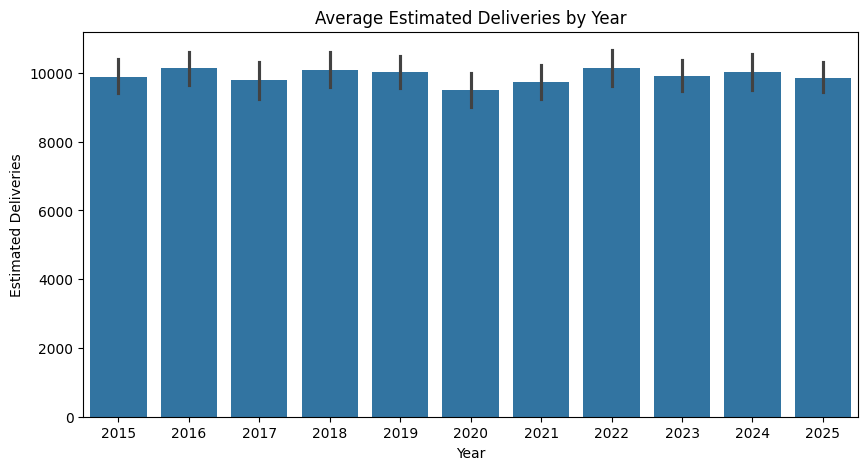

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Year",
    y="Estimated_Deliveries",
    estimator=np.mean
)

plt.title("Average Estimated Deliveries by Year")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.show()

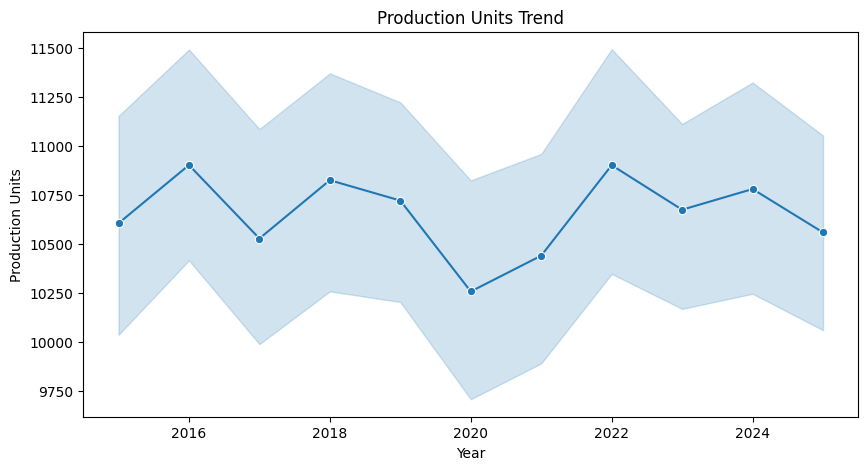

In [8]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Year",
    y="Production_Units",
    marker="o"
)

plt.title("Production Units Trend")
plt.xlabel("Year")
plt.ylabel("Production Units")

plt.show()

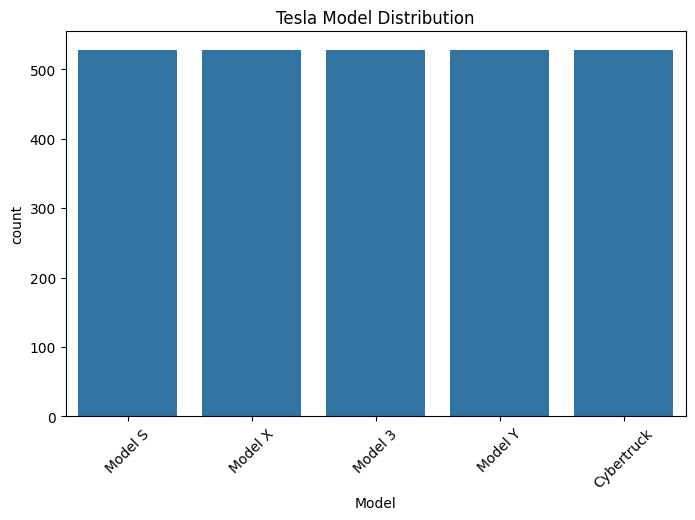

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Model"
)

plt.xticks(rotation=45)

plt.title("Tesla Model Distribution")

plt.show()

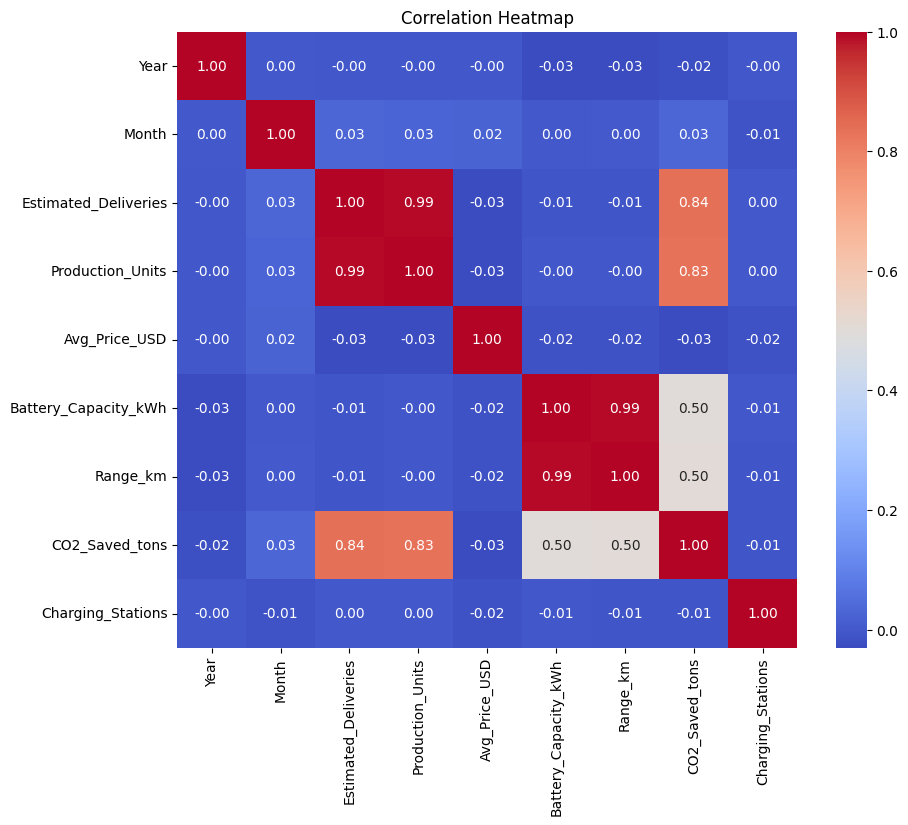

In [10]:
plt.figure(figsize=(10,8))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

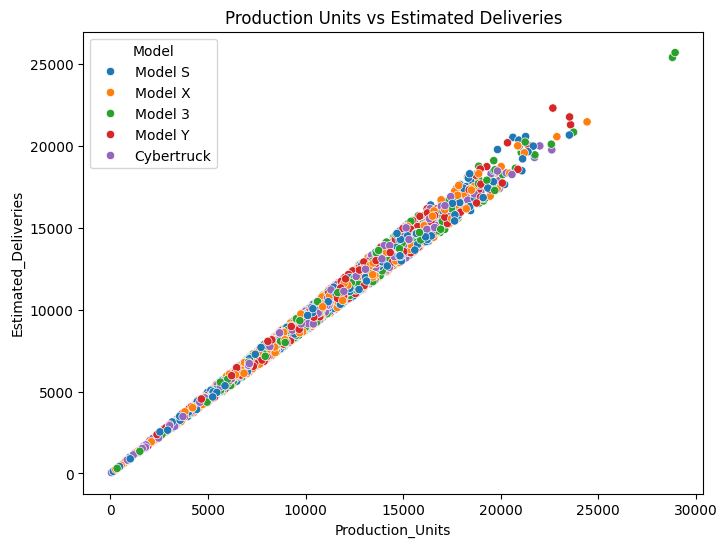

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries",
    hue="Model"
)

plt.title("Production Units vs Estimated Deliveries")

plt.show()

## EDA Summary

From the above visualizations we observe:

- Estimated deliveries vary across different years.
- Production units generally follow a similar trend to deliveries.
- Tesla models are evenly represented in the dataset.
- Numerical variables exhibit varying degrees of correlation.
- Production Units and Estimated Deliveries show a positive relationship.

# Feature Engineering

Feature Engineering improves the dataset by converting categorical variables into numerical values and creating additional features that can help improve machine learning model performance.

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Month",
    "Region",
    "Model",
    "Source_Type"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("Categorical variables encoded successfully.")

df.head()

Categorical variables encoded successfully.


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,4,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,1,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,0,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,1,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,11,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [13]:
# Create previous month's deliveries feature
df["Previous_Deliveries"] = df["Estimated_Deliveries"].shift(1)

# Create rolling mean feature
df["Rolling_Mean_Deliveries"] = (
    df["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

# Remove rows containing NaN values created by shift/rolling
df.dropna(inplace=True)

print("Feature engineering completed.")

df.head()

Feature engineering completed.


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Previous_Deliveries,Rolling_Mean_Deliveries
2,2019,0,3,3,8411,9189,117887.32,82,480,605.59,1,14071,3797.0,9951.333333
3,2021,1,3,1,6555,7311,89294.91,120,712,700.07,2,9333,8411.0,6254.333333
4,2016,11,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,6555.0,9113.333333
5,2020,3,0,3,4656,5043,86930.57,82,477,333.14,2,5798,12374.0,7861.666667
6,2015,10,0,1,7717,7976,87588.21,82,475,549.84,1,9961,4656.0,8249.000000


# Preparing Data for Machine Learning

The dataset is now split into:

- Features (X)
- Target Variable (y)

The target variable is **Estimated_Deliveries**.

In [14]:
X = df.drop("Estimated_Deliveries", axis=1)

y = df["Estimated_Deliveries"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2638, 13)
Target Shape: (2638,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (2110, 13)
Testing Data: (528, 13)


# Linear Regression Model

Linear Regression is used as the baseline regression model to predict the Estimated Deliveries based on the available features.

In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


# Model Evaluation

The model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression Performance\n")

print("MAE :", round(mean_absolute_error(y_test, y_pred),2))

print("RMSE :", round(np.sqrt(mean_squared_error(y_test, y_pred)),2))

print("R2 Score :", round(r2_score(y_test, y_pred),4))

Linear Regression Performance

MAE : 306.78
RMSE : 371.19
R2 Score : 0.9909


# Random Forest Regression

Random Forest is an ensemble learning algorithm that often provides better prediction accuracy than Linear Regression.

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


# Random Forest Evaluation

In [19]:
print("Random Forest Performance\n")

print("MAE :", round(mean_absolute_error(y_test, rf_pred),2))

print("RMSE :", round(np.sqrt(mean_squared_error(y_test, rf_pred)),2))

print("R2 Score :", round(r2_score(y_test, rf_pred),4))

Random Forest Performance

MAE : 327.72
RMSE : 430.29
R2 Score : 0.9878


# Hyperparameter Tuning

GridSearchCV is used to find the best parameters for the Random Forest model.

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}


# Feature Importance

Feature importance helps identify which features contribute most to predicting Tesla estimated deliveries.

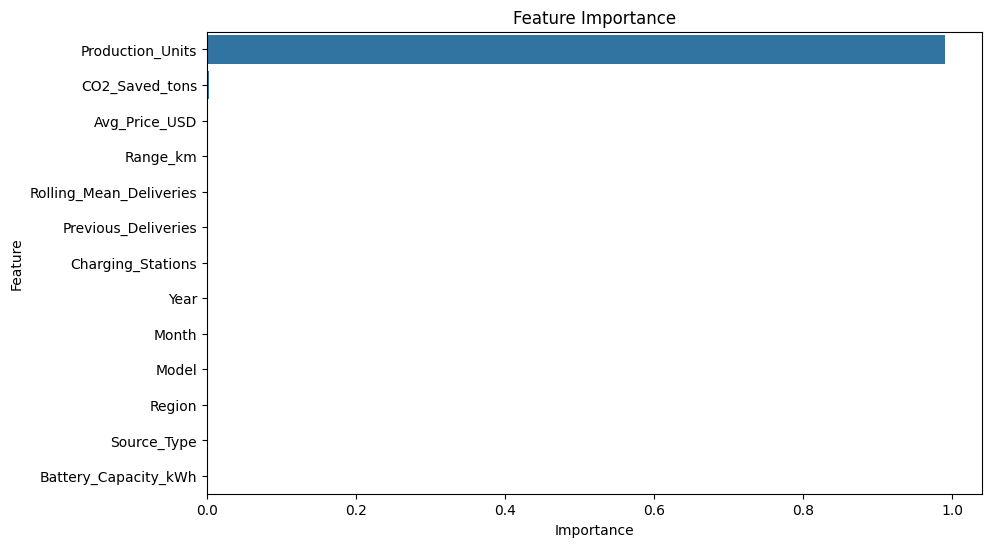

,Feature,Importance
4,Production_Units,0.990125
8,CO2_Saved_tons,0.002223
5,Avg_Price_USD,0.001123
7,Range_km,0.001078
12,Rolling_Mean_Deliveries,0.001067
11,Previous_Deliveries,0.001052
10,Charging_Stations,0.000926
0,Year,0.000667
1,Month,0.000617
3,Model,0.000426


In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

importance

# Actual vs Predicted Deliveries

The following comparison shows how closely the Linear Regression model predicts the actual delivery values.

In [22]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,14733,14775.372194
1,5997,6061.127877
2,12865,12694.346663
3,10695,10717.688903
4,15813,15522.537250
5,9362,9834.173381
6,7384,7173.698651
7,7656,7735.737096
8,14551,15171.143912
9,16396,16554.150325


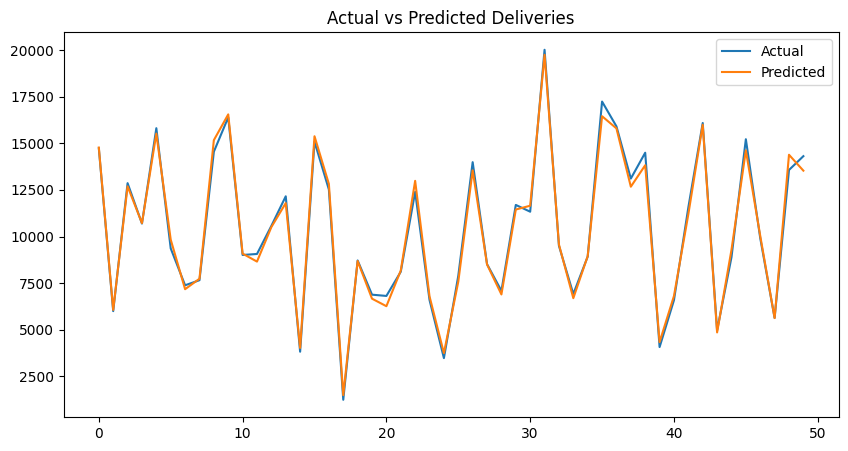

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    comparison["Actual"].values[:50],
    label="Actual"
)

plt.plot(
    comparison["Predicted"].values[:50],
    label="Predicted"
)

plt.title("Actual vs Predicted Deliveries")

plt.legend()

plt.show()

# Time Series Visualization

This visualization illustrates the trend of estimated Tesla deliveries over time.

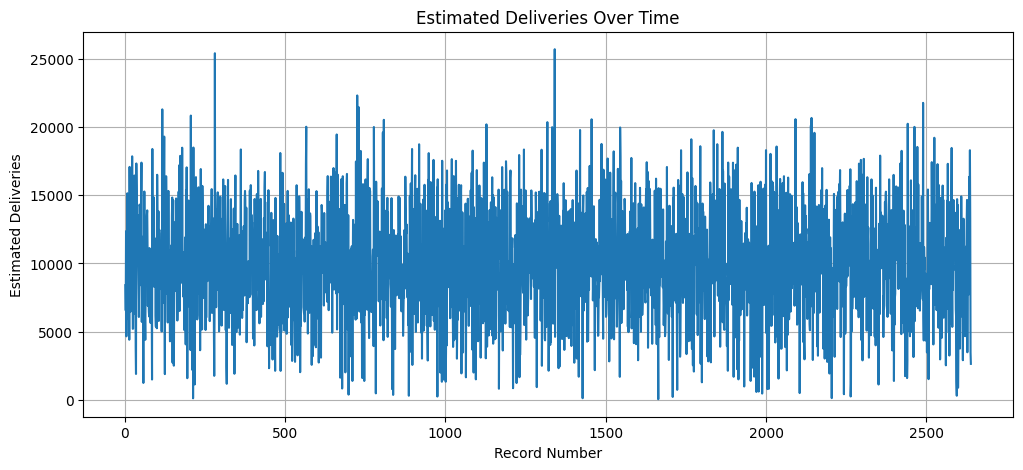

In [24]:
plt.figure(figsize=(12,5))

plt.plot(df["Estimated_Deliveries"])

plt.title("Estimated Deliveries Over Time")

plt.xlabel("Record Number")

plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

# Conclusion

This notebook successfully demonstrates an end-to-end Machine Learning pipeline using the Tesla EA Deliveries and Production dataset.

## Tasks Completed

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Train-Test Split
- Linear Regression
- Random Forest Regression
- Hyperparameter Tuning using GridSearchCV
- Model Evaluation
- Feature Importance Analysis
- Time Series Visualization

The project demonstrates a complete workflow from raw data preprocessing to predictive modeling and evaluation.